Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.083e+14, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(


Training ElasticNet Regression...


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.020e+14, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(


Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Support Vector Regression...
Training K-Nearest Neighbors...
Training XGBoost...

Model Performance:
                        Model           RMSE  R² Score
5              Random Forest  146388.673917  0.858248
9                    XGBoost  147991.934471  0.855126
6          Gradient Boosting  149569.524769  0.852021
8        K-Nearest Neighbors  182430.952780  0.779853
4              Decision Tree  205102.530502  0.721736
0          Linear Regression  212539.516638  0.701190
2           Lasso Regression  212539.632581  0.701190
1           Ridge Regression  212567.759640  0.701111
3      ElasticNet Regression  228402.180319  0.654923
7  Support Vector Regression  400889.679366 -0.063077


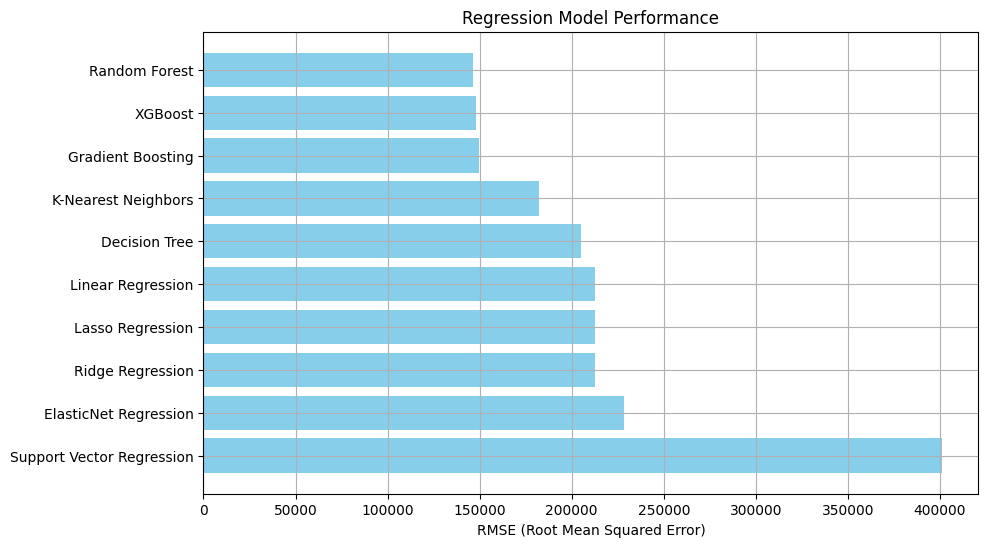

In [14]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Load dataset
df = pd.read_csv("D:/ml_lern/data/kc_house_data.csv")

# Preprocess data
df = df.drop(["id", "date"], axis=1)
df = df.dropna()

X = df.drop("price", axis=1)
y = df["price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor()
}

# Train, predict, and evaluate
results = []
for name, model in models.items():
    print(f"Training {name}...")
    if name in ["Support Vector Regression", "K-Nearest Neighbors"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((name, rmse, r2))

# Display results
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R² Score"]).sort_values(by="RMSE")
print("\nModel Performance:\n", results_df)

# Plot RMSE comparison
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["RMSE"], color="skyblue")
plt.xlabel("RMSE (Root Mean Squared Error)")
plt.title("Regression Model Performance")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.083e+14, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.020e+14, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(


Model performance:
                        Model           RMSE  R² Score
9                    XGBoost  147991.934471  0.855126
5              Random Forest  148245.106227  0.854630
6          Gradient Boosting  148370.248550  0.854384
8        K-Nearest Neighbors  182430.952780  0.779853
4              Decision Tree  210866.432072  0.705876
0          Linear Regression  212539.516638  0.701190
2           Lasso Regression  212539.632581  0.701190
1           Ridge Regression  212567.759640  0.701111
3      ElasticNet Regression  228402.180319  0.654923
7  Support Vector Regression  400889.679366 -0.063077


C:\Users\User\AppData\Local\Temp\ipykernel_5432\3154039175.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="RMSE", y="Model", data=results_df, ax=axes[0], palette="Blues_r")
C:\Users\User\AppData\Local\Temp\ipykernel_5432\3154039175.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R² Score", y="Model", data=results_df, ax=axes[1], palette="Greens")


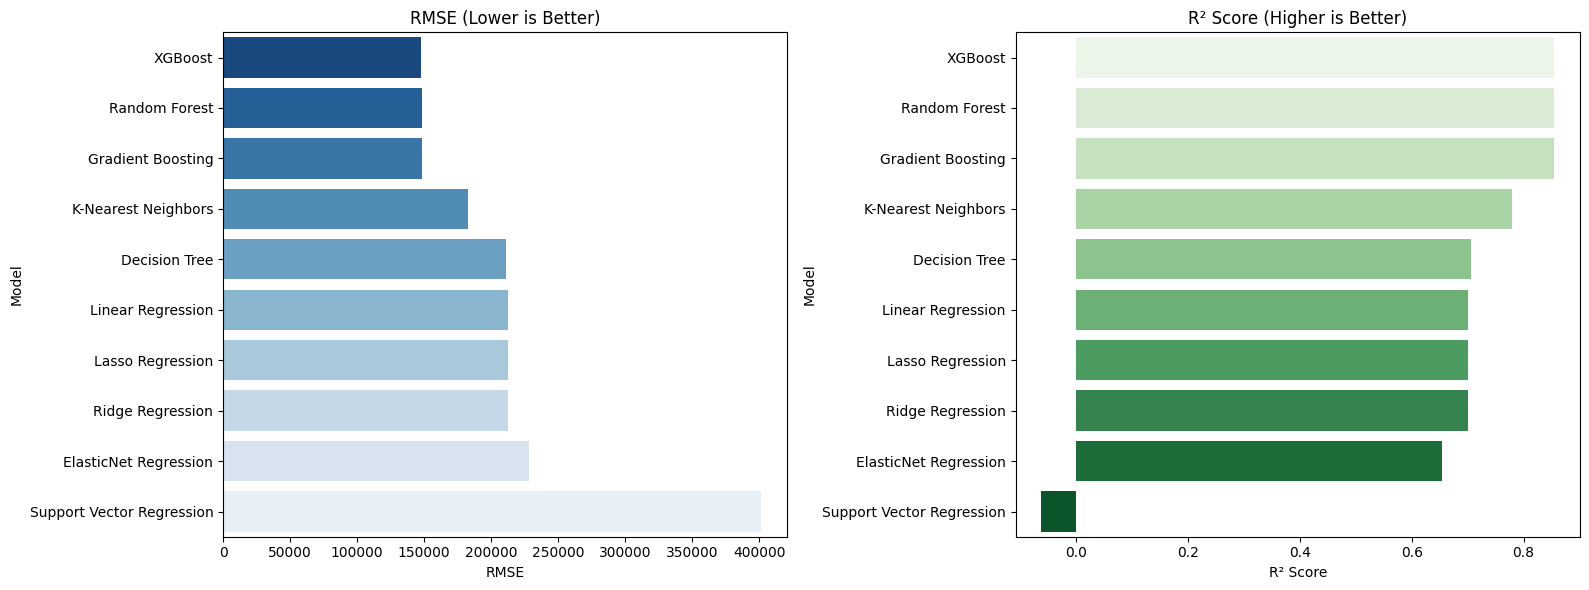

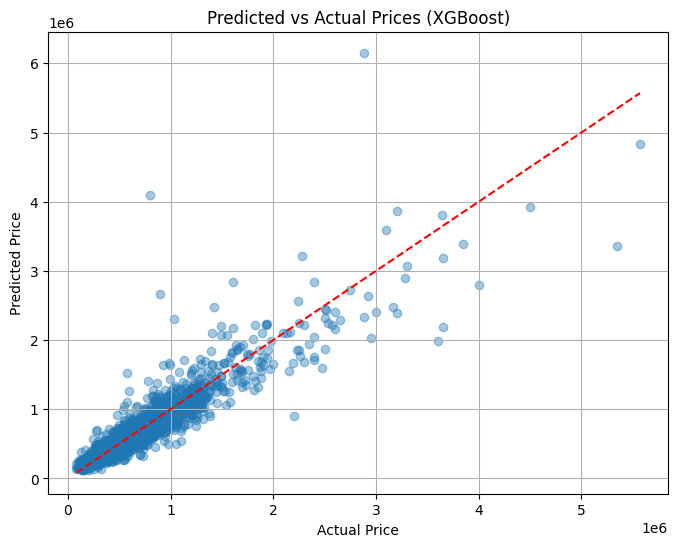

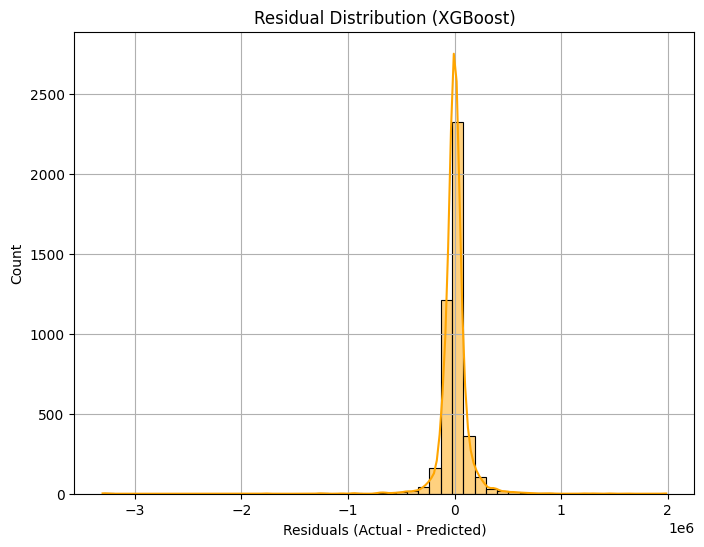

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Load dataset
df = pd.read_csv("D:/ml_lern/data/kc_house_data.csv")
df = df.drop(["id", "date"], axis=1)
df = df.dropna()

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor()
}

results = []
predictions = {}

for name, model in models.items():
    if name in ["Support Vector Regression", "K-Nearest Neighbors"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((name, rmse, r2))
    predictions[name] = y_pred

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R² Score"]).sort_values(by="RMSE")

print("Model performance:\n", results_df)

# Plot RMSE and R2 side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x="RMSE", y="Model", data=results_df, ax=axes[0], palette="Blues_r")
axes[0].set_title("RMSE (Lower is Better)")
axes[0].set_xlabel("RMSE")

sns.barplot(x="R² Score", y="Model", data=results_df, ax=axes[1], palette="Greens")
axes[1].set_title("R² Score (Higher is Better)")
axes[1].set_xlabel("R² Score")

plt.tight_layout()
plt.show()

# Get best model predictions (lowest RMSE)
best_model_name = results_df.iloc[0]["Model"]
best_y_pred = predictions[best_model_name]

# Scatter plot: Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual Prices ({best_model_name})")
plt.grid(True)
plt.show()

# Residual plot for best model
residuals = y_test - best_y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True, color="orange")
plt.xlabel("Residuals (Actual - Predicted)")
plt.title(f"Residual Distribution ({best_model_name})")
plt.grid(True)
plt.show()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.083e+14, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.020e+14, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(


Model performance:
                        Model           RMSE  R² Score
5              Random Forest  145907.882899  0.859177
9                    XGBoost  147991.934471  0.855126
6          Gradient Boosting  149872.550470  0.851420
8        K-Nearest Neighbors  182430.952780  0.779853
4              Decision Tree  200276.029797  0.734678
0          Linear Regression  212539.516638  0.701190
2           Lasso Regression  212539.632581  0.701190
1           Ridge Regression  212567.759640  0.701111
3      ElasticNet Regression  228402.180319  0.654923
7  Support Vector Regression  400889.679366 -0.063077


C:\Users\User\AppData\Local\Temp\ipykernel_5432\4241543714.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="RMSE", y="Model", data=results_df, ax=axes[0], palette="Blues_r")
C:\Users\User\AppData\Local\Temp\ipykernel_5432\4241543714.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R² Score", y="Model", data=results_df, ax=axes[1], palette="Greens")


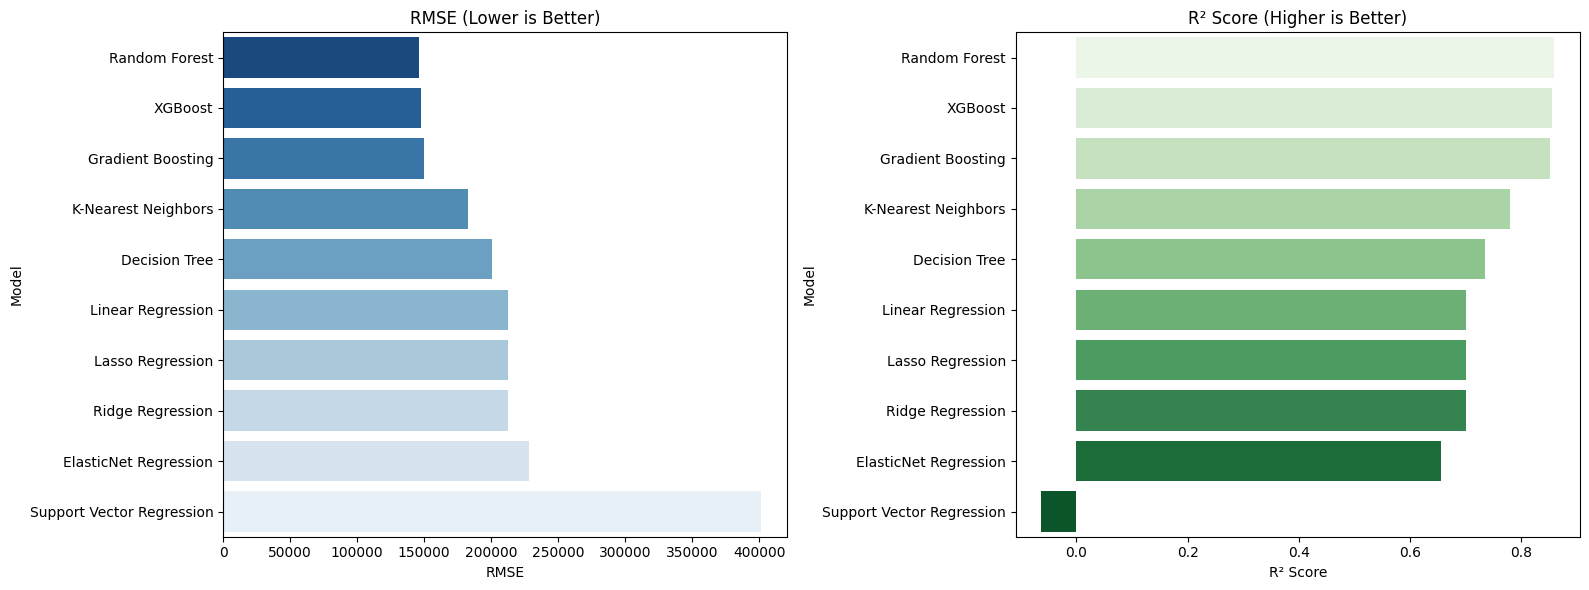

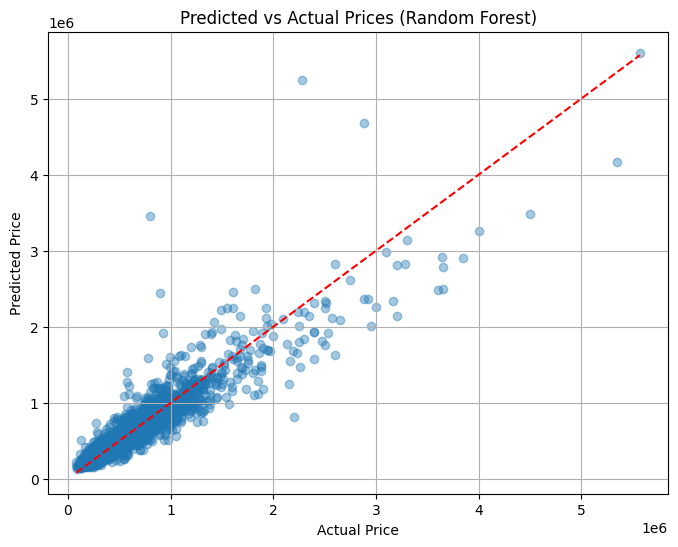

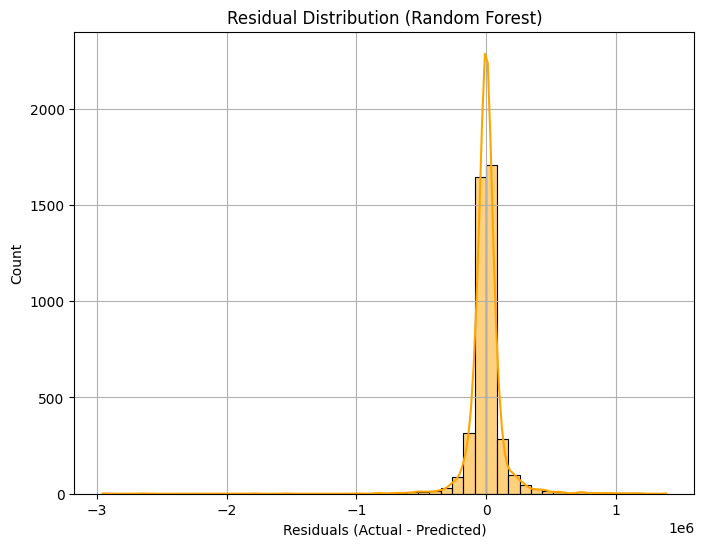

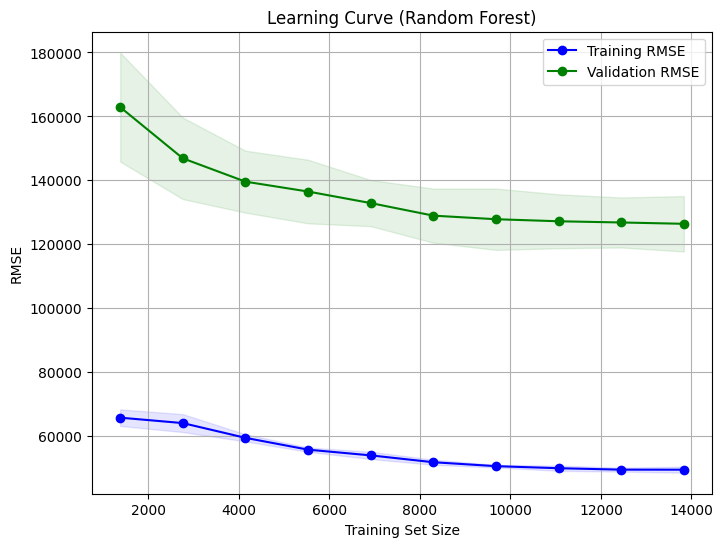

C:\Users\User\AppData\Local\Temp\ipykernel_5432\4241543714.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


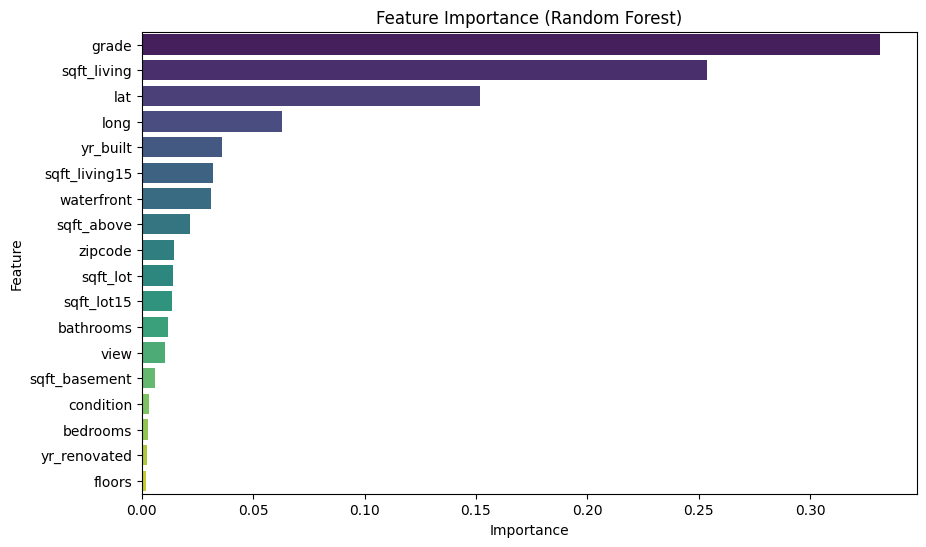

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Load and preprocess
df = pd.read_csv("D:/ml_lern/data/kc_house_data.csv")
df = df.drop(["id", "date"], axis=1)
df = df.dropna()

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet Regression": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor()
}

results = []
predictions = {}

for name, model in models.items():
    if name in ["Support Vector Regression", "K-Nearest Neighbors"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((name, rmse, r2))
    predictions[name] = y_pred

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R² Score"]).sort_values(by="RMSE")

print("Model performance:\n", results_df)

# Plot RMSE and R2 side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x="RMSE", y="Model", data=results_df, ax=axes[0], palette="Blues_r")
axes[0].set_title("RMSE (Lower is Better)")
axes[0].set_xlabel("RMSE")

sns.barplot(x="R² Score", y="Model", data=results_df, ax=axes[1], palette="Greens")
axes[1].set_title("R² Score (Higher is Better)")
axes[1].set_xlabel("R² Score")

plt.tight_layout()
plt.show()

# Best model info
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_y_pred = predictions[best_model_name]

# Predicted vs Actual scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual Prices ({best_model_name})")
plt.grid(True)
plt.show()

# Residuals histogram
residuals = y_test - best_y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True, color="orange")
plt.xlabel("Residuals (Actual - Predicted)")
plt.title(f"Residual Distribution ({best_model_name})")
plt.grid(True)
plt.show()

# ----------------------
# Learning Curve function
def plot_learning_curve(estimator, X, y, title="Learning Curve", cv=5):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=cv,
                                                          scoring='neg_mean_squared_error',
                                                          train_sizes=np.linspace(0.1, 1.0, 10),
                                                          n_jobs=-1)
    train_rmse = np.sqrt(-train_scores)
    val_rmse = np.sqrt(-val_scores)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_rmse.mean(axis=1), 'o-', color='blue', label='Training RMSE')
    plt.plot(train_sizes, val_rmse.mean(axis=1), 'o-', color='green', label='Validation RMSE')
    plt.fill_between(train_sizes, 
                     train_rmse.mean(axis=1) - train_rmse.std(axis=1),
                     train_rmse.mean(axis=1) + train_rmse.std(axis=1),
                     alpha=0.1, color='blue')
    plt.fill_between(train_sizes, 
                     val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                     val_rmse.mean(axis=1) + val_rmse.std(axis=1),
                     alpha=0.1, color='green')
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot learning curve for best model
if best_model_name in ["Support Vector Regression", "K-Nearest Neighbors"]:
    plot_learning_curve(best_model, X_train_scaled, y_train, title=f"Learning Curve ({best_model_name})")
else:
    plot_learning_curve(best_model, X_train, y_train, title=f"Learning Curve ({best_model_name})")

# ----------------------
# Feature Importance for tree models
def plot_feature_importance(model, X, model_name):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feat_names = X.columns
        imp_df = pd.DataFrame({"Feature": feat_names, "Importance": importances}).sort_values(by="Importance", ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")
        plt.title(f"Feature Importance ({model_name})")
        plt.show()
    else:
        print(f"{model_name} does not support feature importance.")

# Plot feature importance if applicable
if best_model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    plot_feature_importance(best_model, X_train, best_model_name)
else:
    print(f"Feature importance not available for {best_model_name}.")
